In [14]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from scipy.spatial import ConvexHull

# Preparation

## 1. Define the system of units ($G=M=a=1$)
+ Mass of the primary star: $M_1$, mass of the companion star: $M_2$; Total mass: $M=M_1+M_2$
+ Separation: $a$
+ Angular momentum: $\Omega$
+ Rotation period: $P$
+ Ratio of mass: $q=M_2/M_1$
+ Proportion of $M_2$: $\mu = M_2/M$

In [15]:
# Physical constant and parameters
G = 1
M = 1 # M=M1+M2
a = 1 # a=a1+a2, separation between 2 stars
Omega = np.sqrt(G*M/a**3) # Angular velocity = 1 [rad/(P/2π)]
P = 2*np.pi/Omega # Period of the binary system
q, mu, M1, M2, x1, x2 = 0, 0, 0, 0, 0, 0

## 2. Define the co-rotating frame
+ X axis: Companion star ($x_2<0$) - Mass center ($O$) - Primary star ($x_1>0$);
+ XY plane: rotation plane;
+ Z axis: +Z along the angular momentum

### Function: `set_q`
+ **Usage:** set the values of $q$, $mu$, $x_1$, $x_2$, $M_1$, $M_2$
+ **Input:** `q`
+ **Output:**  
  No explicit output arguments.

In [16]:
def set_q(given_q):
    global q, mu, M1, M2, x1, x2
    q = given_q # q=M2/M1
    mu = q/(1+q) # mu=M2/M
    x1 = a*mu
    x2 = -a*(1-mu)
    M2 = M*mu
    M1 = M-M2

## 3. Define functions related to the Roche potentials and Lagrange points

### Function (1): `calc_roche_potential`
+ **Usage:** Calculate the Roche potential $\Phi_{Roche}=\Phi_{g,1}+\Phi_{g,2}-\Phi_{centrifugal}$ at a given 2D position $(x,y,0)$
+ **Input:** `x`, `y` (Coordinates of the point where the Roche potential is evaluated)
+ **Input:** $\epsilon$ (softening factor in the calculation of distances of the given position from 2 stars)
+ **Output:** Value of Roche potential $\Phi_{Roche}$

---

### Function (2): `calc_roche_potential_3D`
+ **Usage:** Calculate the Roche potential $\Phi_{Roche}=\Phi_{g,1}+\Phi_{g,2}-\Phi_{centrifugal}$ at a given 2D position $(x,y,z)$
+ **Input:** `x`, `y` ,`z`(Coordinates of the point where the Roche potential is evaluated)
+ **Input:** $\epsilon$ (softening factor in the calculation of distances of the given position from 2 stars)
+ **Output:** Value of Roche potential $\Phi_{Roche}$

---

### Function (3): `sgn`
+ **Usage:** Evaluate the sign function
  $$
  \operatorname{sgn}(x)=
  \begin{cases}
  +1, & x>0, \\
  0, & x=0, \\
  -1, & x<0 .
  \end{cases}
  $$

+ **Input:** `x`  
  A scalar or NumPy array.

+ **Output:**  
  The sign of `x`, with the same shape as the input.

+ **Remarks:**  
  This function is used in the equation defining the collinear Lagrangian points.

---

### Function (4): `calc_d_roche_potential_along_x`
+ **Usage:** Evaluate the 1D equation whose roots determine the collinear Lagrangian points $L_1$, $L_2$, and $L_3$ along the $x$-axis:
  $$
  f(x)=x-\frac{1-\mu}{(x-\mu)^2}\operatorname{sgn}(x-\mu)-\frac{\mu}{(x-\mu+1)^2}\operatorname{sgn}(x-\mu+1)
  $$

+ **Input:** `x`  
  The $x$ coordinate where the function is evaluated.

+ **Output:**  
  The value of $f(x)$.

---

### Function (5): `calc_bisect_root`
+ **Usage:** Find the root of a function inside a given interval using the **bisection method**.

+ **Input:** `func`  
  The function whose root is to be found.

+ **Input:** `ledge`, `redge`  
  The left and right boundaries of the search interval.

+ **Input:** `err`  
  Desired numerical accuracy for the root.

+ **Output:**  
  Approximate value of the root satisfying $f(x)=0$ within the interval $[\texttt{ledge},\texttt{redge}]$.

+ **Remarks:**  
  The algorithm checks whether the interval is valid (finite function values and opposite signs at the endpoints).  
  If the interval is invalid, an error message is printed and the function returns `None`.

---

### Function (6): `calc_lagrange_points`
+ **Usage:** Calculate the positions of the five Lagrangian points.

+ For the **collinear points** $L_1$, $L_2$, and $L_3$, the function solves
  $$
  f(x)=x-\frac{1-\mu}{(x-\mu)^2}\operatorname{sgn}(x-\mu)-\frac{\mu}{(x-\mu+1)^2}\operatorname{sgn}(x-\mu+1)=0
  $$
  using the bisection method.

+ For the **triangular points** $L_4$ and $L_5$, the analytical expressions are used:
  $$
  (x_{L4},y_{L4})=\left(\mu-\frac12,\frac{\sqrt3}{2}\right)
  $$
  $$
  (x_{L5},y_{L5})=\left(\mu-\frac12,-\frac{\sqrt3}{2}\right)
  $$

+ **Input:**  
  No explicit input arguments.

+ **Output:**  
  A list containing the coordinates of the five Lagrangian points:
  [[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]

In [17]:
def calc_roche_potential(x, y, epsilon=0.01):
    if q==0:
        print("Error: have not set q!")
        return
    r = np.sqrt(x**2 + y**2) # Distance of the object from the origin
    r1 = np.sqrt((x - x1)**2 + y**2) # Distance between the object and the primary star
    r2 = np.sqrt((x - x2)**2 + y**2) # Distance between the object and the companion star
    
    # Soften r1 and r2 to avoid division by zero
    r1_eff = np.sqrt(r1**2 + epsilon**2)
    r2_eff = np.sqrt(r2**2 + epsilon**2)
    
    # Roche Potential = Gravitational (M1) + Gravitational (M2) + Centrifugal potential
    phi1 = - (G * M1)/r1_eff
    phi2 = - (G * M2)/r2_eff
    phiC = (1/2) * (Omega**2) * (r**2)
    phi_Roche = phi1 + phi2 - phiC
    
    return phi_Roche

def calc_roche_potential_3D(x, y, z, epsilon=0.01):
    if q==0:
        print("Error: have not set q!")
        return
    r = np.sqrt(x**2 + y**2 + z**2) # Distance of the object from the origin
    r1 = np.sqrt((x - x1)**2 + y**2 + z**2) # Distance between the object and the primary star
    r2 = np.sqrt((x - x2)**2 + y**2 + z**2) # Distance between the object and the companion star
    
    # Soften r1 and r2 to avoid division by zero
    r1_eff = np.sqrt(r1**2 + epsilon**2)
    r2_eff = np.sqrt(r2**2 + epsilon**2)
    
    # Roche Potential = Gravitational (M1) + Gravitational (M2) + Centrifugal potential
    phi1 = - (G * M1)/r1_eff
    phi2 = - (G * M2)/r2_eff
    phiC = (1/2) * (Omega**2) * (x**2 + y**2)
    phi_Roche = phi1 + phi2 - phiC
    
    return phi_Roche

def sgn(x):
    return np.where(x>0,1.0, np.where(x<0,-1.0,0.0))

def calc_d_roche_potential_along_x(x):
    return (x-(1-mu)/((x-mu)**2)*sgn(x-mu)-mu/((x-mu+1)**2)*sgn(x-mu+1))

def calc_bisect_root(func, ledge, redge, err=1e-8):
    fl, fr = func(ledge), func(redge)
    if not np.isfinite(fl) or not np.isfinite(fr) or fl*fr > 0:
        print("Error: bad interval for the bisection method")
        return None
    while abs(ledge-redge)>err:
        m = 0.5*(ledge+redge)
        fm = func(m)
        if fl*fm <= 0:
            redge, fr = m, fm
        else:
            ledge, fl = m, fm
    return 0.5*(ledge+redge)

def calc_lagrange_points():
    if q==0:
        print("Error: have not set q!")
        return
    xmin, xmax = -2.0, 2.0
    eps = 1e-6
    # Numerical solutions for L1, L2. L3
    xL1 = calc_bisect_root(lambda x: calc_d_roche_potential_along_x(x), mu-1+eps, mu-eps)
    xL2 = calc_bisect_root(lambda x: calc_d_roche_potential_along_x(x), xmin, mu-1-eps)
    xL3 = calc_bisect_root(lambda x: calc_d_roche_potential_along_x(x), mu+eps, xmax)
    yL1, yL2, yL3 = 0, 0, 0
    # Analytical solutions for L1, L2. L3
    xL4, xL5 = mu-1/2, mu-1/2
    yL4, yL5 = np.sqrt(3)/2, -np.sqrt(3)/2
    return [[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]

## 4. Define plotting functions and the function to calculate the volume of the Roche lobe of the companion

### Function (1): `plot_2D_Roche_equipotentials_xyplane`
+ **Usage:** Plot the **two-dimensional Roche equipotential contours** in the orbital plane and display the positions of the two stars and the five Lagrangian points.

+ **Input:** `lagrangian_points`  
  A list containing the coordinates of the five Lagrangian points:  
  `[[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]`

+ **Output:** `fig`, `ax`

---

### Function (2): `plot_3D_Roche_equipotentials_xyplane`
+ **Usage:** Plot the **three-dimensional Roche potential surface** in the orbital plane and visualize the equipotential corresponding to the $L_1$ point.

+ **Input:** `lagrangian_points`  
  A list containing the coordinates of the five Lagrangian points:  
  `[[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]`

+ **Output:** `fig`, `ax`

+ **Remarks:**  
  To avoid the singular behaviour near the two stars, the plotted potential values are clipped to a finite percentile range.  

---

### Function (3): `plot_d_Roche_potential_along_x`
+ **Usage:** Plot the function
  $$
  f(x)=x-\frac{1-\mu}{(x-\mu)^2}\operatorname{sgn}(x-\mu)-\frac{\mu}{(x-\mu+1)^2}\operatorname{sgn}(x-\mu+1)
  $$
  along the $x$-axis in order to visualize the roots corresponding to the collinear Lagrangian points $L_1$, $L_2$, and $L_3$.

+ **Input:** `lagrangian_points`  
  A list containing the coordinates of the five Lagrangian points:  
  `[[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]`

+ **Output:** `fig`, `ax`

---

### Function (4): `find_smallest_component`
+ **Usage:** Identify the smallest connected component in a triangulated surface mesh.

+ **Input:** `faces`  
  An array containing the triangle indices defining the mesh faces:  
  `faces.shape = (M,3)`

+ **Output:** `faces_smallest`

+ **Remarks:**  
  Two triangles are considered connected if they share a common edge.  
  The connected components are identified by graph traversal on the face adjacency relation, and the smallest one is returned.

---

### Function (5): `calc_mesh_volume`
+ **Usage:** Compute the volume enclosed by a triangulated surface mesh.

+ **Input:** `verts`  
  Array containing the coordinates of the mesh vertices.

+ **Input:** `faces`  
  Array containing the triangle indices defining the mesh surface.

+ **Output:** `volume`

+ **Remarks:**  
  The volume is calculated by summing the signed volumes of tetrahedra formed by each triangular face and a reference point inside the mesh.

---

### Function (6): `plot_roche_lobe`
+ **Usage:** Reconstruct and plot the three-dimensional Roche lobe surface corresponding to the equipotential passing through $L_1$.

+ **Input:** `ax`  
  
+ **Input:** `lagrangian_points`  
  A list containing the coordinates of the five Lagrangian points:  
  `[[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]`

+ **Input:** `sim_range`  
  Size of the cubic computational domain used to evaluate the Roche potential.

+ **Input:** `N`  
  Number of grid divisions in each spatial direction.

+ **Output:** `fig`, `ax`

+ **Remarks:**  
  The equipotential surface corresponding to the Roche potential value at $L_1$ is extracted from a three-dimensional grid using the marching cubes algorithm.  
  If several disconnected surfaces are found, the smallest connected component is selected as the Roche lobe.

---

### Function (7): `calc_roche_lobe_volume`
+ **Usage:** Compute the volume of the Roche lobe of the companion star.

+ **Input:** `lagrangian_points`  
  A list containing the coordinates of the five Lagrangian points:  
  `[[xL1,yL1],[xL2,yL2],[xL3,yL3],[xL4,yL4],[xL5,yL5]]`

+ **Input:** `sim_range`  
  Size of the cubic computational domain used to evaluate the Roche potential.

+ **Input:** `N`  
  Number of grid divisions in each spatial direction.

+ **Output:** `volume`, `volume_convex`, `volume_mesh`

+ **Remarks:**  
  The Roche-lobe volume is estimated using three different methods: grid point counting, convex hull estimation, and triangulated mesh volume calculation.

---

In [18]:
def plot_2D_Roche_equipotentials_xyplane(lagrangian_points):
    delta = 0.0005
    size = 2
    x = np.arange(-size, size, delta)
    y = np.arange(-size, size, delta)
    # Define the grid
    X, Y = np.meshgrid(x, y)
    Z =calc_roche_potential(X, Y)
    # Avoid the deep wells around 2 stars
    zmin, zmax = np.percentile(Z, [30, 100])
    levels = np.linspace(zmin, zmax, 30)
    
    xL1 = lagrangian_points[0][0]
    xL2 = lagrangian_points[1][0]
    xL3 = lagrangian_points[2][0]
    xL4 = lagrangian_points[3][0]
    xL5 = lagrangian_points[4][0]
    yL1 = lagrangian_points[0][1]
    yL2 = lagrangian_points[1][1]
    yL3 = lagrangian_points[2][1]
    yL4 = lagrangian_points[3][1]
    yL5 = lagrangian_points[4][1]

    # Calculate Roche potentials of all the Lagrangian points
    RP_L1 = calc_roche_potential(xL1, yL1)
    RP_L2 = calc_roche_potential(xL2, yL2)
    RP_L3 = calc_roche_potential(xL3, yL3)
    RP_L4 = calc_roche_potential(xL4, yL4)
    RP_L5 = calc_roche_potential(xL5, yL5)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    
    
    RP_Ls = np.array([RP_L1, RP_L2, RP_L3, RP_L4, RP_L5])
    RP_Ls = np.unique(RP_Ls)
    RP_Ls.sort()
    
    # Basic Roche equipotentials
    CS_base = ax.contour(
        X, Y, Z,
        levels=levels,
        colors='black',
        linewidths=0.4
    )
    # Roche equipotentials for Lagrangian points
    CS_Ls = ax.contour(
        X, Y, Z,
        levels=RP_Ls.tolist(),
        colors='black',
        linewidths=2.0
    )
    # Roche equipotential for L1 (highlight)
    CS_L1 = ax.contour(
        X, Y, Z,
        levels=[RP_L1],
        colors='blue',
        linewidths=2.0
    )

    ax.plot(0, 0, 'k+', ms=10) # CM
    ax.plot(x1, 0, 'ko', ms=5) # M1
    ax.plot(x2, 0, 'ko', ms=5) # M2
    ax.text(x1+0.01, -0.01, r'$M_1$', color='k', fontsize=10, va='top', ha='left')
    ax.text(x2+0.01, -0.01, r'$M_2$', color='k', fontsize=10, va='top', ha='left')

    ax.plot(xL1, 0, 'r^', ms=6)
    ax.text(xL1+0.03, 0.02, r'$L_1$', fontsize=11, color='r')
    ax.plot(xL2, 0, 'r^', ms=6)
    ax.text(xL2-0.10, 0.02, r'$L_2$', fontsize=11, color='r')
    ax.plot(xL3, 0, 'r^', ms=6)
    ax.text(xL3+0.03, 0.02, r'$L_3$', fontsize=11, color='r')
    ax.plot(xL4, yL4, 'r^', ms=6)
    ax.text(xL4+0.03, yL4+0.03, r'$L_4$', fontsize=11, color='r')
    ax.plot(xL5, yL5, 'r^', ms=6)
    ax.text(xL5+0.03, yL5-0.08, r'$L_5$', fontsize=11, color='r')

    ax.set_title(rf"Roche equipotentials with Lagrange points ($q={q}$)", fontsize=14)
    return fig, ax

def plot_3D_Roche_equipotentials_xyplane(lagrangian_points):
    delta = 0.0005
    size = 2
    x = np.arange(-size, size, delta)
    y = np.arange(-size, size, delta)
    # Define the grid
    X, Y = np.meshgrid(x, y)
    Z =calc_roche_potential(X, Y)
    
    # Avoid singularities of Roche potential
    Zplot = np.clip(Z, np.percentile(Z, 0.8), np.percentile(Z, 100))
    
    xL1 = lagrangian_points[0][0]
    xL2 = lagrangian_points[1][0]
    xL3 = lagrangian_points[2][0]
    xL4 = lagrangian_points[3][0]
    xL5 = lagrangian_points[4][0]
    yL1 = lagrangian_points[0][1]
    yL2 = lagrangian_points[1][1]
    yL3 = lagrangian_points[2][1]
    yL4 = lagrangian_points[3][1]
    yL5 = lagrangian_points[4][1]
    
    # Calculate Roche potential of L1
    zL1 = calc_roche_potential(xL1, yL1)
    zL2 = calc_roche_potential(xL2, yL2)
    zL3 = calc_roche_potential(xL3, yL3)
    zL4 = calc_roche_potential(xL4, yL4)
    zL5 = calc_roche_potential(xL5, yL5)
    
    fig = plt.figure(figsize=(10, 7), dpi=300)
    ax = fig.add_subplot(111, projection='3d')
    ax.set_zlim(min(Zplot.min(), zL1), max(Zplot.max(), zL1))

    ax.plot_surface(
        X, Y, Zplot,
        rstride=100, cstride=100,
        color='white',
        edgecolor='k',
        linewidth=0.3,
        shade=False,
        alpha=0.3
    )
    
    # Only visualize region with r <= 1.4 to avoid the outer equipotential of L1
    Rmask = np.sqrt(X**2 + Y**2)
    mask = Rmask > 1.4
    Z_masked = np.ma.array(Z, mask=mask)
    
    ax.contour3D(X, Y, Z_masked, levels=[zL1], colors='r', linewidths=3.0)
    
    # Plot the 5 Lagrangian points
    ax.scatter(
        [xL1, xL2, xL3, xL4, xL5],
        [yL1, yL2, yL3, yL4, yL5],
        [zL1, zL2, zL3, zL4, zL5],
        color='blue',
        s=35,
        depthshade=False
    )
    ax.text(xL1, yL1, zL1, r'  $L_1$', color='blue', fontsize=11)
    ax.text(xL2, yL2, zL2, r'  $L_2$', color='blue', fontsize=11)
    ax.text(xL3, yL3, zL3, r'  $L_3$', color='blue', fontsize=11)
    ax.text(xL4, yL4, zL4, r'  $L_4$', color='blue', fontsize=11)
    ax.text(xL5, yL5, zL5, r'  $L_5$', color='blue', fontsize=11)
    
    ax.set_xlabel('x[a]')
    ax.set_ylabel('y[a]')
    ax.set_zlabel(r'$\Phi_{\rm Roche}[GM/a]$')
    ax.set_box_aspect((1, 1, 0.3))
    # View
    ax.view_init(elev=35, azim=-60)
    ax.set_title(rf"Roche potential for $q={q}$", fontsize=14)

    return fig, ax

def plot_d_Roche_potential_along_x(lagrangian_points):
    xL1 = lagrangian_points[0][0]
    xL2 = lagrangian_points[1][0]
    xL3 = lagrangian_points[2][0]
    
    xmin, xmax = -2.0, 2.0
    eps = 1e-6
    xs1 = np.linspace(xmin, mu-1-eps, 4000)
    xs2 = np.linspace(mu-1+eps, mu-eps, 4000)
    xs3 = np.linspace(mu+eps, xmax, 4000)
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    ax.plot(xs1, calc_d_roche_potential_along_x(xs1), 'b', lw=1)
    ax.plot(xs2, calc_d_roche_potential_along_x(xs2), 'r', lw=1)
    ax.plot(xs3, calc_d_roche_potential_along_x(xs3), 'g', lw=1)

    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(mu-1, color='gray', lw=0.8, ls='--')
    ax.axvline(mu,   color='gray', lw=0.8, ls='--')

    ax.set_title(
        r"$f(x)=x-\frac{1-\mu}{(x-\mu)^2}\operatorname{sgn}(x-\mu)"
        r"-\frac{\mu}{(x-\mu+1)^2}\operatorname{sgn}(x-\mu+1)$"
        f",  $q={q}$", fontsize=15
    )
    ax.set_xlabel("x[a]",fontsize=13)
    ax.set_ylabel(rf'$f(x[a])[GM/a^2]$',fontsize=13)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.set_ylim(-10, 10)

    ax.plot(0, 0, 'k+', ms=10)      # CM
    ax.plot(x1, 0, 'ko', ms=5)      # M1
    ax.plot(x2, 0, 'ko', ms=5)      # M2

    # Lagrange points
    ax.plot(xL2, calc_d_roche_potential_along_x(xL2), 'b^', ms=5)
    ax.plot(xL1, calc_d_roche_potential_along_x(xL1), 'r^', ms=5)
    ax.plot(xL3, calc_d_roche_potential_along_x(xL3), 'g^', ms=5)

    ax.text(xL2+0.01, calc_d_roche_potential_along_x(xL2)-0.3, ' L2', color='b', fontsize=12,
             va='top', ha='left')
    ax.text(xL1+0.01, calc_d_roche_potential_along_x(xL1)-0.3, ' L1', color='r', fontsize=12,
             va='top', ha='left')
    ax.text(xL3+0.01, calc_d_roche_potential_along_x(xL3)-0.3, ' L3', color='g', fontsize=12,
             va='top', ha='left')

    ax.text(x1+0.01, -0.3, ' M1', color='k', fontsize=12,
             va='top', ha='left')
    ax.text(x2+0.01, -0.3, ' M2', color='k', fontsize=12,
             va='top', ha='left')
    ax.text(-2, -2.5,
             rf'$x(L_1)={xL1:.8f}a$' '\n'
             rf'$x(L_2)={xL2:.8f}a$' '\n'
             rf'$x(L_3)={xL3:.8f}a$',
             fontsize=12, ha='left', va='top')

    return fig, ax

def find_smallest_component(faces):
    # faces: (M,3) triangles index into verts
    # M:number of faces
    M = faces.shape[0]

    edge2tris = {}
    for t, (a,b,c) in enumerate(faces):
        edges = [(a,b),(b,c),(c,a)]
        for u,v in edges:
            if u > v: u, v = v, u
            # For each edge, remember the indexes of the faces that include it
            edge2tris.setdefault((u,v), []).append(t)

    adj = [[] for _ in range(M)]
    
    # Make a map recording the connected faces of each face
    for tris in edge2tris.values():
        if len(tris) == 2:
            t1, t2 = tris
            adj[t1].append(t2)
            adj[t2].append(t1)

    # Mark each face with the number of faces in the connected surface where it is
    comp_id = -np.ones(M, dtype=int)
    comp_sizes = []
    cid = 0
    for i in range(M):
        # If id!=-1, it means this face has been classified into a connected surface
        if comp_id[i] != -1: 
            continue
        stack = [i]
        comp_id[i] = cid
        size = 0
        while stack:
            t = stack.pop()
            size += 1
            for nb in adj[t]:
                if comp_id[nb] == -1:
                    comp_id[nb] = cid
                    stack.append(nb)
        comp_sizes.append(size)
        cid += 1

    # Select the faces on the smallest connected surface
    smallest = int(np.argmin(comp_sizes))
    keep = (comp_id == smallest)
    return faces[keep]

def calc_mesh_volume(verts, faces):    
    tri = verts[faces]
    
    v0 = tri[:, 0, :]
    v1 = tri[:, 1, :]
    v2 = tri[:, 2, :]
    unique_vertices = np.unique(
        np.vstack((v0, v1, v2)),
        axis=0
    )
    origin = unique_vertices.mean(axis=0)
    vol = np.einsum('ij,ij->i', v0-origin, np.cross(v1-origin, v2-origin)) / 6.0
    return abs(vol.sum())

def plot_roche_lobe(ax, lagrangian_points, sim_range = 4, N = 200):
    x_L1_q = lagrangian_points[0][0]
    x_L2_q = lagrangian_points[1][0]
    
    # Mesh range = 4, small enough to save the calculation resource
    # but big enough to cover the whole Roche lobes
   
    N+=1
    x_list = sim_range * np.linspace(-0.5, 0.5, N)
    y_list = sim_range * np.linspace(-0.5, 0.5, N)
    z_list = sim_range * np.linspace(-0.5, 0.5, N)

    grid = np.meshgrid(x_list, y_list, z_list, indexing='ij')
    X, Y, Z = grid[0], grid[1], grid[2]
    mesh_Roche = calc_roche_potential_3D(X, Y, Z)
        
    dX = X[1,0,0] - X[0,0,0]
    dY = Y[0,1,0] - Y[0,0,0]
    dZ = Z[0,0,1] - Z[0,0,0]

    L1_Roche = calc_roche_potential_3D(x_L1_q, 0, 0)

    # Obtain the equipotential surface of L1 (linear interpolation on the 3D mesh)
    verts, faces, normals, values = measure.marching_cubes(
        mesh_Roche, level=L1_Roche, spacing = (dX, dY, dZ)
    )

    # Move the coordinates of vertices on the L1 equipotential back to their physical values
    verts_phys = verts.copy()
    verts_phys[:, 0] += X.min()
    verts_phys[:, 1] += Y.min()
    verts_phys[:, 2] += Z.min()
    
    # Select the indexes of faces constituting the smallest connnected surface
    faces_lobe = find_smallest_component(faces)
    faces_lobe_points = np.unique(faces_lobe)
    
    # Select vertices on the smallest connected surface
    verts_lobe = verts_phys[faces_lobe_points]
    distance_to_L1 = np.min(np.linalg.norm(verts_lobe-np.array([x_L1_q,0,0]),axis=1))
    
    # If the Roche lobe is not the smallest connected component, 
    # it means the outer part of the L1 equipotential surface is smaller than the surface of the Roche lobe
    # so, by increasing the mesh range, we can probably make the former one greater than the latter.
    if distance_to_L1 > dX:
        print("Error: ")
        sim_range = sim_range*2
        print("Retry: mesh range = ", sim_range)
        plot_roche_lobe(lagrangian_points, sim_range, N-1)
    
    #fig = plt.figure(figsize=(10, 6), dpi=300)
    #fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98)
    #ax = fig.add_subplot(111, projection='3d')
    ax.plot_trisurf(
        verts_phys[:, 0], verts_phys[:, 1], verts_phys[:, 2],
        triangles=faces_lobe,
        cmap='Spectral',
        linewidth=0.2
    )

    ax.set_box_aspect((2, 1, 1)) 
    ax.set_xlabel('x[a]')
    ax.set_ylabel('y[a]')
    ax.set_zlabel('z[a]')
    ax.set_xlim(-1.2,1.2)
    ax.set_ylim(-0.5,0.5)
    ax.set_zlim(-0.5,0.5)
    #ax.set_title(rf"Roche lobe ($q={q:.3f}$)")
    ax.text2D(
        0.1, 0.8,
        "Roche lobe, " rf"$q={q:.3f}$",
        transform=ax.transAxes,
        fontsize=12,
        ha='left',
        va='top'
    )
    ax.view_init(elev=30, azim=-90)
    
    return ax

def calc_roche_lobe_volume(lagrangian_points, sim_range = 4, N = 200):
    x_L1_q = lagrangian_points[0][0]
    x_L2_q = lagrangian_points[1][0]
    # Distance between the companion star and L2 point
    R_L2 = mu-1-x_L2_q
    
    # Mesh range = 4, small enough to save the calculation resource
    # but big enough to cover the whole Roche lobes

    N+=1
    x_list = sim_range * np.linspace(-0.5, 0.5, N)
    y_list = sim_range * np.linspace(-0.5, 0.5, N)
    z_list = sim_range * np.linspace(-0.5, 0.5, N)

    grid = np.meshgrid(x_list, y_list, z_list, indexing='ij')
    X, Y, Z = grid[0], grid[1], grid[2]
    mesh_Roche = calc_roche_potential_3D(X, Y, Z)
        
    dX = X[1,0,0] - X[0,0,0]
    dY = Y[0,1,0] - Y[0,0,0]
    dZ = Z[0,0,1] - Z[0,0,0]

    L1_Roche = calc_roche_potential(x_L1_q, 0)
    
    # Calculate the volume of Roche lobe of the companion star with the proportion of the points within it
    # Number of points with Roche potential smaller than that of L1 
    # && with x smaller than x_L1 (left side of L1)
    # && with radii<abs(x(L2))
    points_in_lobe2 = (mesh_Roche < L1_Roche) & (X < x_L1_q) & ((X**2+Y**2+Z**2) <= x_L2_q**2)
    volume = mesh_Roche[points_in_lobe2].size/mesh_Roche.size*sim_range**3    
    
    # Obtain the equipotential surface of L1 (linear interpolation on the 3D mesh)
    verts, faces, normals, values = measure.marching_cubes(
        mesh_Roche, level=L1_Roche, spacing = (dX, dY, dZ)
    )

    # Move the coordinates of vertices on the L1 equipotential back to their physical values
    verts_phys = verts.copy()
    verts_phys[:, 0] += X.min()
    verts_phys[:, 1] += Y.min()
    verts_phys[:, 2] += Z.min()
    
    # Select the indexes of faces constituting the smallest connnected surface
    faces_lobe = find_smallest_component(faces)
    faces_lobe_points=np.unique(faces_lobe)
    
    # Select vertices on the smallest connected surface
    verts_lobe = verts_phys[faces_lobe_points]
    distance_to_L1 = np.min(np.linalg.norm(verts_lobe-np.array([x_L1_q,0,0]),axis=1))
    
    # If the Roche lobe is not the smallest connected component, 
    # it means the outer part of the L1 equipotential surface is smaller than the surface of the Roche lobe
    # so, by increasing the mesh range, we can probably make the former one greater than the latter.
    if distance_to_L1 > dX:
        print("Error: ")
        sim_range = sim_range*2
        print("Retry: mesh range = ", sim_range)
        calc_roche_lobe_volume(lagrangian_points, sim_range, N-1)
    
    # Select only the vertices of the Roche lobe of the companion star
    verts_lobe_companion = verts_lobe[verts_lobe[:, 0]<x_L1_q]
    
    # Calculate the volume of the smallest convex polyhedron of those vertices
    volume_convex = ConvexHull(verts_lobe_companion).volume
    
    # Select faces constituting the smallest connnected surface with all 3 vertices'x < x(L1) 
    mask_faces = (verts_phys[faces_lobe][:, :, 0] < x_L1_q).all(axis=1) 
    faces_companion = faces_lobe[mask_faces]
    
    # Calculate the volume by summing up the volumes of all tetrahedrons 
    # with the selected face vertices and the origin as their vertices
    volume_mesh = calc_mesh_volume(verts_phys, faces_companion)
    
    return volume,volume_convex, volume_mesh

## 1- Equipotential surfaces of a binary system
+ Consider the non-inertial corotating frame and use the Cartesian coordinate system
+ Hydrostatic equilibrium in this frame:
    $$
    \frac{1}{\rho}\,\vec{\nabla}P = -\vec{\nabla}\Phi_{\mathrm{Roche}}, \tag{1}
    $$
+ Roche potential: 
    $$
    \Phi_{\mathrm{Roche}} = \Phi_{\mathrm{g,1}}+\Phi_{\mathrm{g,2}}-\Phi_{\mathrm{centrifugal}}, \tag{2}
    $$
    where $\Phi_{\mathrm{g,i}}$ is the gravitational potential of star i, and $\Phi_{\mathrm{centrifugal}}$ is the centrifugal potential in the non-inertial frame: $\Phi_{\mathrm{centrifugal}}=\frac{1}{2}\Omega^2(x^2+y^2)$
+ Using the Roche approximation:
    $$
    \Phi_i = -\frac{GM_i}{|\vec{r}-\vec{r}_i|}, \tag{3}
    $$
+ Roche potential can be expressed as: 
    $$
    \Phi_{\mathrm{Roche}} = -\frac{GM_i}{|\vec{r}-\vec{r}_1|}+-\frac{GM_i}{|\vec{r}-\vec{r}_2|}-\frac{1}{2}\Omega^2(x^2+y^2). \tag{4} 
    $$

Let's set $q=0.25$

In [19]:
set_q(0.25)

### 1-1 Plot the equipotentials of the Roche potential

In [20]:
lagrange_points = calc_lagrange_points()
fig_2D_Roche, ax_2D_Roche = plot_2D_Roche_equipotentials_xyplane(lagrange_points)
fig_3D_Roche, ax_3D_Roche = plot_3D_Roche_equipotentials_xyplane(lagrange_points)

<class 'numpy._core._exceptions._ArrayMemoryError'>: Unable to allocate 488. MiB for an array with shape (8000, 8000) and data type float64

## 2- Calculate the positions of Lagrange points 
In the previous plots of equipotentials of Roche potential, we have already marked the Lagrange points. They are obtained by the equilibrium condition:
    $$
    \vec{\nabla}\Phi_{\mathrm{Roche}} = 0. \tag{5}
    $$
+ Collinear Lagrange points L1, L2, and L3: To obtain their x positions, we need to solve the zero points of
    $$
    \frac{\partial \Phi_{\mathrm{Roche}}}{\partial x} = 0, \tag{6}
    $$
    which under the Roche approximation is 
    $$
    f(x)=x-\frac{1-\mu}{(x-\mu)^2}\operatorname{sgn}(x-\mu)-\frac{\mu}{(x-\mu+1)^2}\operatorname{sgn}(x-\mu+1)=0. \tag{7}
    $$
We solve it with bisection method numerically.
+ Triangular Lagrange points L4, L5: their analytical positions are
    $$
    (x_{L4},y_{L4})=\left(\mu-\frac12,\frac{\sqrt3}{2}\right), \tag{8}
    $$
    $$
    (x_{L5},y_{L5})=\left(\mu-\frac12,-\frac{\sqrt3}{2}\right). \tag{9}
    $$
    
Here, we plot the function $(7)$ and mark the x positions of L1, L2 and L3.

In [ ]:
fig_solve_collinear, ax_solve_collinear = plot_d_Roche_potential_along_x(lagrange_points)

## 3- Roche lobe
The equipotential passing through the point L1 defines a “Roche lobe” around each star. 
### 3-1 The visualization of the Roche lobe for $q=0.25$.

In [ ]:
fig_Roche_lobe = plt.figure(figsize=(10, 6), dpi=300)
ax_Roche_lobe = fig_Roche_lobe.add_subplot(projection='3d')
ax_Roche_lobe = plot_roche_lobe (ax_Roche_lobe, lagrange_points)

### 3-2 With the increasing of the mass ratio $q$, the Roche lobe of the companion is getting bigger and bigger.

In [ ]:
q_values = [0.02, 0.1, 0.3, 0.5, 0.7, 1.0]
n = len(q_values)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig_Roche_lobe_vs_q = plt.figure(figsize=(4.5 * ncols, 3.8 * nrows), dpi=300)
for i, q_val in enumerate(q_values, start=1):
    set_q(q_val)
    lagrangian_points = calc_lagrangian_points()
    ax = fig_Roche_lobe_vs_q.add_subplot(nrows, ncols, i, projection='3d')
    ax = plot_roche_lobe(ax, lagrangian_points, sim_range=4, N=200)
plt.tight_layout()

### 3-3 Numerically calculate the volume of the Roche lobe of the companion star (star 2) with 3 methods.
+ **Grid-point counting (`volume`)**: approximate the volume ratio of the Roche lobe of star 2 with the grid ratio within it.
    $$
    V_{grid}\approx \frac{N_{in}}{N_{tot}} V_{box}, \tag{10}
    $$
where $N_{in}$ is the number of grid points within the lobe, $N_{tot}$ is the number of all the grid points covering the whole Roche lobe region, and $V_{box}$ is the volume of the region of all the grid points. The resolution of this method mainly comes from the resolution of the grids, and when the resolution of the grid is not high enough, the error of the calculated volume will be the greatest among those from the 3 methods.
- **Convex-hull volume (`volume_convex`)**: the volume is computed as that of the smallest convex polyhedron enclosing the selected Roche-lobe vertices. So if the shape of the vertices is not perfectly convex, the calculated volume will be higher that the true volume, which means the convex-hull volume will give an upper bound.
- **Mesh-based volume (`volume_mesh`)**: the volume is obtained from the triangulated Roche-lobe surface reconstructed with the marching cubes algorithm. The mesh-based estimate is expected to be the most reliable, since it follows the reconstructed equipotential surface directly.

### 3-4 Estimate the resolution and reliability of the mesh-based volume method with different numbers of 1D grid points

In [24]:
volume_results = {}
q_test = [0.02, 0.1, 0.3, 0.6, 1.0]
N_test = [50, 80, 100, 150, 200, 250, 300, 350, 400, 600]

for q_val in q_test:
    set_q(q_val)
    lagrangian_points = calc_lagrangian_points()
    
    data = []
    for N in N_test:
        volume, volume_convex, volume_mesh = calc_roche_lobe_volume(
            lagrangian_points, sim_range=4, N=N
        )
        data.append((N, volume, volume_convex, volume_mesh))
    
    volume_results[q_val] = data

<class 'NameError'>: name 'calc_lagrangian_points' is not defined

In [ ]:
for q_val, data in volume_results.items():
    V_ref = data[-1][3]   # last volume_mesh
    print(f"\nq = {q_val}")
    for N, volume, volume_convex, volume_mesh in data:
        rel_err = abs(volume_mesh - V_ref) / V_ref
        print(f"N={N:3d}, Vmesh={volume_mesh:.8f}, rel.err={rel_err:.3e}")

#### Generally, if we consider the precision of mesh-based volume is the high enough to make it very close to the real value when N=600, the resolution of mesh-based volume is estimated to be higher than 1% for q>=0.02 if N=400. Therefore, it is reasonable and reliable to set N=400 to estimate the volumes of the Roche lobe of star 2 for different q.

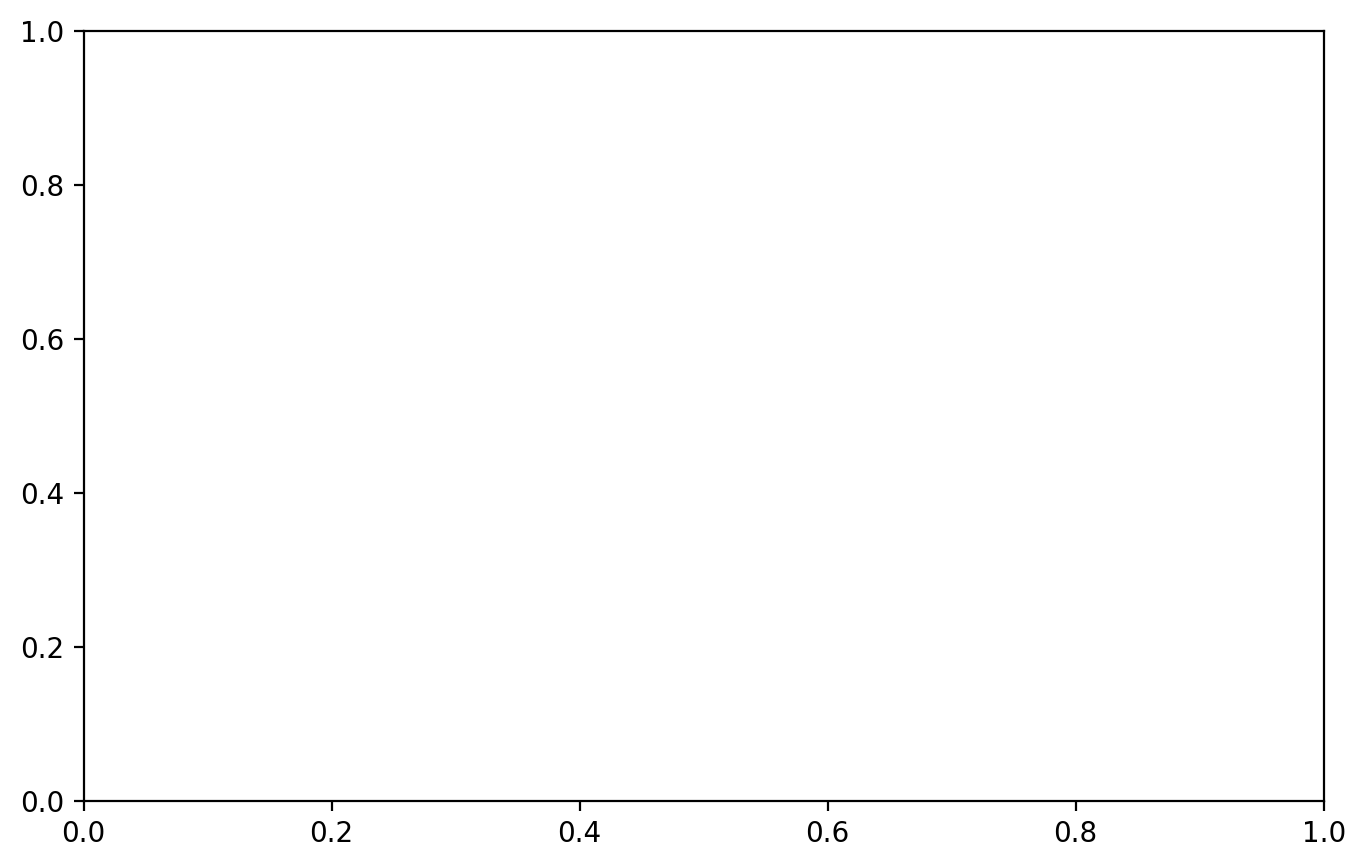

<class 'NameError'>: name 'volume_results' is not defined

In [21]:
fig_mesh_volume, ax_mesh_volume = plt.subplots(figsize=(8,5), dpi=200)

for q_val, data in volume_results.items():
    N_arr = np.array([row[0] for row in data])
    V_arr = np.array([row[3] for row in data])  # volume_mesh
    V_ref = V_arr[-1]
    err_arr = np.abs(V_arr - V_ref) / V_ref
    
    ax_mesh_volume.plot(N_arr[:-1], err_arr[:-1], 'o-', label=rf'$q={q_val}$')

ax_mesh_volume.set_xlabel('N', fontsize=13)
ax_mesh_volume.set_ylabel(r'Relative error of $V_{\rm mesh}$', fontsize=13)
ax_mesh_volume.set_yscale('log')
ax_mesh_volume.set_title('Relative error of 'r'$V_{\rm mesh}$' ' compared to ' r'$V_{\rm mesh, N=600}$', fontsize=15)
ax_mesh_volume.grid(True, ls='--', alpha=0.5)
ax_mesh_volume.legend()
plt.tight_layout()

### 3-5 Compare the approximation given by Paczynski with the numerical value of the volume of the Roche lobe of the companion star.
Considering the mesh-based volumes at N = 600 to be the numerical results of the Roche lobe volume of star 2, estimate the relative error of the approximation given by Paczynski at different mass ratio $q$. 
+ Paczynski approximation:
    $$
    R_2 \approx \beta \mu^3, \beta\approx 0.462. \tag{11}
    $$
+ Conclusion 1: the relative error of the Paczynski approximation is smaller than 5% for $q\in [0.02,0.7]$. But when $q>0.7$, it gets worse, and the error can reach 10% for $q=1$.
+ Conclusion 2: It is the most accurate for $q \in (0.4,0.6)$, with error almost always smaller than 2%.

In [22]:
volume_list = []
volume_convex_list = []
volume_mesh_list = []
q_list = np.linspace(0.02, 1.0, 50)
for i in q_list:
    set_q(i)
    lagrangian_points = calc_lagrangian_points()
    volume, volume_convex, volume_mesh = calc_roche_lobe_volume(lagrangian_points, sim_range = 4, N = 400)
    volume_list.append(volume)
    volume_convex_list.append(volume_convex)
    volume_mesh_list.append(volume_mesh)

<class 'NameError'>: name 'calc_lagrangian_points' is not defined

In [23]:
def plot_roche_lobe_volume_vs_q(q_list,
                                volume_list,
                                volume_mesh_list,
                                volume_convex_list,
                                beta=0.462):

    fig = plt.figure(figsize=(10, 6), dpi=300)
    ax = fig.add_subplot(111)

    # theoretical volume
    mu_list = q_list / (1 + q_list)
    R_list = beta * mu_list**(1/3)
    theor_volume = 4*np.pi/3 * R_list**3

    ax.plot(q_list, theor_volume,
            'k--', lw=2,
            label=rf"Theory ($R={beta:.3f}\mu^{{1/3}}$)")

    ax.plot(q_list, volume_list,
            'o-', lw=1.8, ms=5,
            label=r"Roche lobe volume (grid)")

    ax.plot(q_list, volume_mesh_list,
            'd-', lw=1.8, ms=5,
            label=r"Roche lobe volume (mesh)")

    ax.plot(q_list, volume_convex_list,
            's:', lw=1.5, ms=4,
            label=r"Convex hull (upper bound)")

    # relative error
    rel_err = (theor_volume - volume_mesh_list) / volume_mesh_list

    ax_err = ax.twinx()
    ax_err.plot(q_list, rel_err,
                'r^-', lw=1.5, ms=5,
                label=r"Relative error $(V_{\rm th}-V_{\rm mesh})/V_{\rm mesh}$")

    ax_err.set_ylabel(r"Relative error", fontsize=14, color='r', rotation=270)
    ax_err.yaxis.set_label_coords(1.09, 0.5)
    ax_err.tick_params(axis='y', labelcolor='r')

    # combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_err.get_legend_handles_labels()

    ax.legend(lines1 + lines2,
              labels1 + labels2,
              frameon=False,
              fontsize=12,
              loc='best')

    ax.set_xlabel(r"Mass ratio $q = M_2/M_1$", fontsize=14)
    ax.set_ylabel(r"Roche lobe volume ($a^3$ units)", fontsize=14)

    ax.set_title("Roche lobe volume vs mass ratio", fontsize=15)

    ax.grid(True, alpha=0.5, linestyle='--')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.25)

    plt.tight_layout()

    return fig, ax

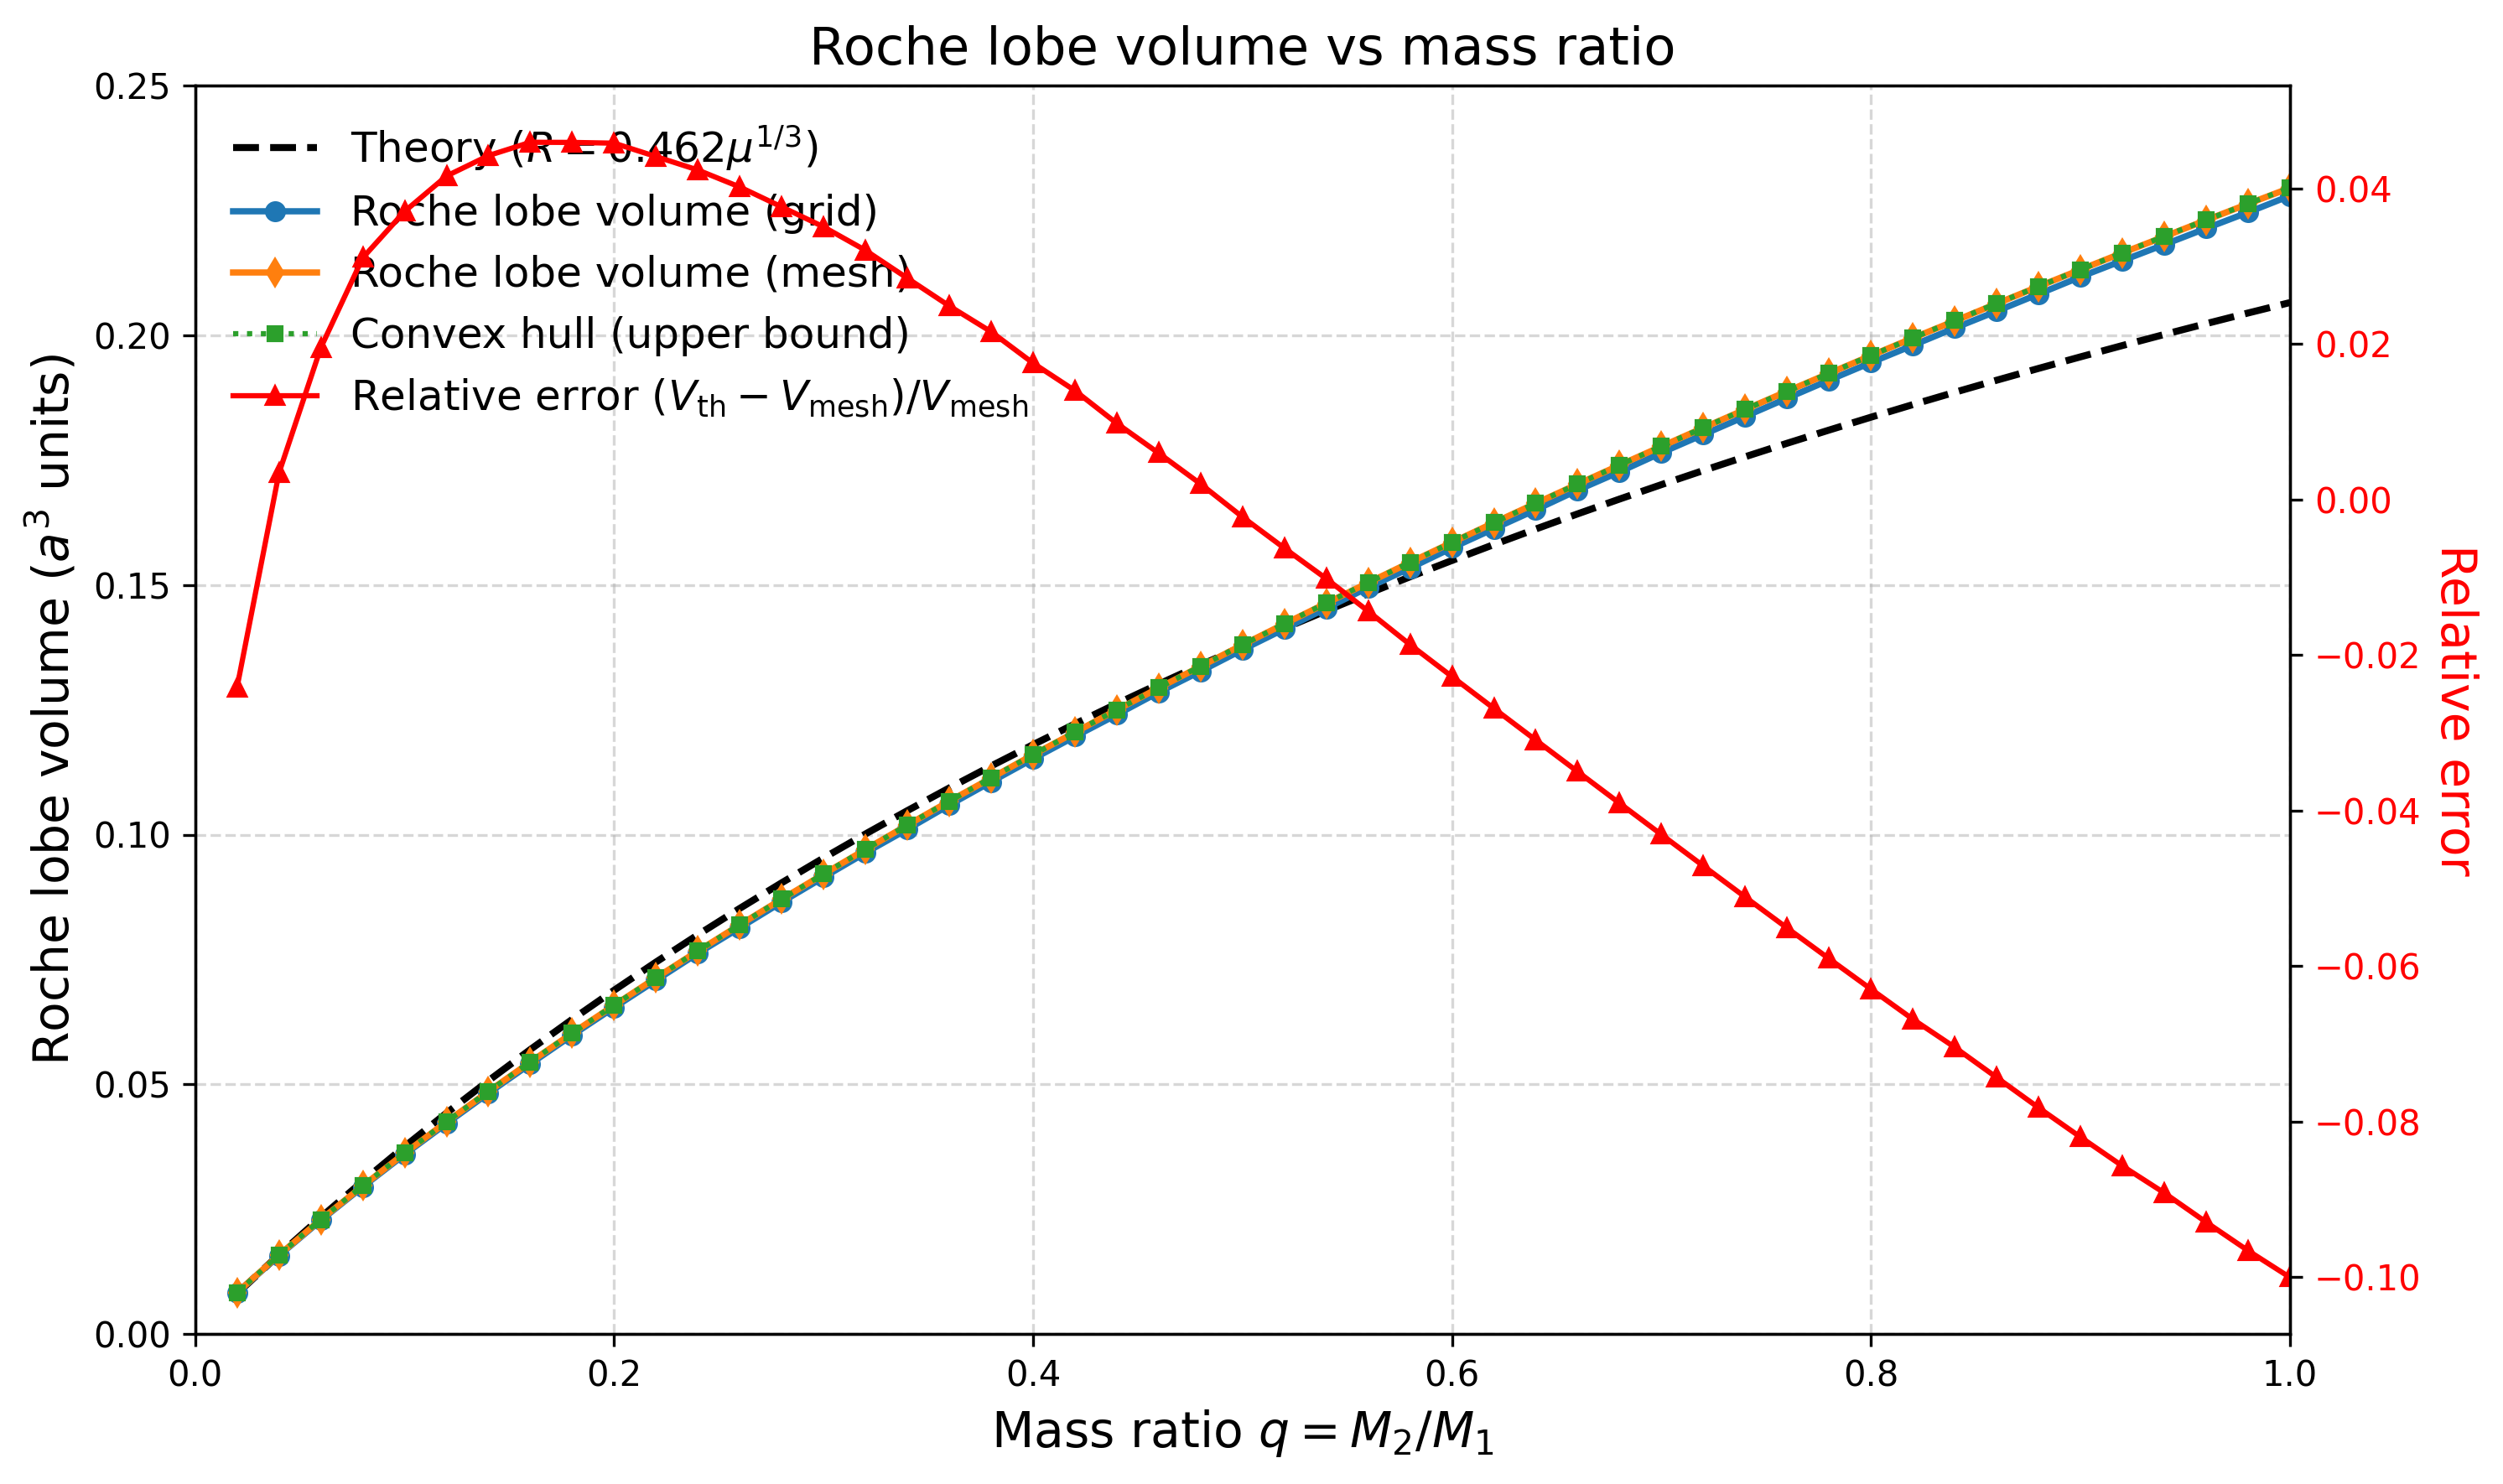

In [114]:
fig_Roche_lobe_volume_vs_q, ax_Roche_lobe_volume_vs_q = plot_roche_lobe_volume_vs_q(
    q_list,
    volume_list,
    volume_mesh_list,
    volume_convex_list
)

### 3-6 Condition for filling the Roche lobe for a mass-radius relation $R_2 \propto M_2^x$

Let us consider a mass-radius relation of the form $R_2 \propto M_2^x$, we want to know under which condition the star 2 will fill its Roche lobe.
By using the Paczinsky approximation, we have that the equivalent radius of the Roche lobe is $\overline{R_2} = \beta a (\frac{M_2}{M})^\frac{1}{3}$. If the second star has filled its Roche lobe, its mean density is :

$$
\overline{\rho_2} = \frac{3 M}{4 \pi \beta^3 a^3}
$$

From the mass-radius relation, we can extract an equality by using a reference star as a normalization factor $R_2 = R_0 (\frac{M_2}{M_0})^x$ and therefore the mean density is :

$$
\rho_2 = \frac{3 M_2}{4 \pi R_0^3} \left(\frac{M_0}{M_2}\right)^{3x}
$$

This leads to the following relation, imposing a value of $\Omega$ for which the Roche lobe is filled :

$$
\Omega = \left(\frac{\beta^3 G M_0}{R_0^3}\right)^\frac{1}{2} \left(\frac{M_0}{M_2}\right)^\frac{3x - 1}{2}
$$

Taking the example of a main sequence star for which $x \approx 1$, and normalizing with the Sun value, we have the following relation :

$$
\Omega = \frac{\sqrt{\beta^3 G}}{M_2} \left(\frac{M_\odot}{R_\odot}\right)^\frac{3}{2}
$$

Or by considering the orbital period instead $P = \frac{2 \pi}{\Omega}$ :

$$
P = \frac{2 \pi M_2}{\sqrt{\beta^3 G}} \left(\frac{R_\odot}{M_\odot}\right)^\frac{3}{2}
$$

Thus the more massive the star the longer the required orbital period. But if we considere a white dwarf, which follows a different mass-radius relation for which $x \approx - \frac{1}{3}$, and by normalizing with value like $M_0 \approx 0.6 M_\odot$ and $R_0 \approx 10^{-2} R_\odot$, which are standard size white dwarf, we get :

$$
\Omega = \left(\frac{\beta^3 G}{6 \cdot 10^{-7} R_\odot^3 M_\odot}\right)^\frac{1}{2} M_2
$$
$$
P = \left(\frac{6 \cdot 10^{-7} R_\odot^3 M_\odot}{\beta^3 G}\right)^\frac{1}{2} \frac{2 \pi}{M_2}
$$

Here the behavior is the opposite, the more massive the star the smaller the orbital period required for filling its Roche lobe. We can deduce that 3 cases are possible. Our system has a given angular velocity $\Omega$, and each star has a required $\Omega$ to fill its Roche lobe, respectively $\Omega_1$ and $\Omega_2$ :

+ $\Omega < \min(\Omega_1, \Omega_2)$, in which case $\Omega$ is not large enough for any star to fill its Roche lobe
+ $\min(\Omega_1, \Omega_2) < \Omega < \max(\Omega_1, \Omega_2)$ in which case one of the two star has its required $\Omega_{1/2} < \Omega$ and therefore can fill its Roche lobe.
+ $\max(\Omega_1, \Omega_2) > \Omega$ in which case $\Omega$ is large enough for both stars to fill their Roche lobes

### 4-1 Mass flux through $L_1$

Now let's suppose that there is matter present near $L_1$, with a characteristic velocity $v$, we want to compute the mass flux through $L_1$. First of all particles near $L_1$ has an energy per unit mass of the order of :

$$
e = \frac{1}{2} v^2 + \Phi_\text{Roche}(\vec{L_1})
$$

Therefore these particles are able to cross any potential barrier less than $e$, we will need to compute the Roche potential near $L_1$ to compute the section which can be crossed, and the mass flux.
If we expand the potential near $L_1$ we have an expression of the form :

$$
\Phi_\text{Roche}(\vec{x}) = \Phi_\text{Roche} (\vec{L_1}) + \vec{\nabla} \Phi_\text{Roche}(\vec{L_1}) \cdot (\vec{x} - \vec{L_1}) + \frac{1}{2} (\vec{x} - \vec{L_1})^T H_{\Phi_\text{Roche}}(\vec{L_1}) (\vec{x} - \vec{L_1})
$$

By definition the gradient of the potential vanishes at $L_1$, so we just have to compute the terms of the Hessian matrix. After doing so we get an expression of the form :

$$
\Phi_\text{Roche}(\vec{x}) = - \frac{G M_1}{\sqrt{(x_L - a_1)^2}} - \frac{G M_2}{\sqrt{(x_L - a_2)^2}} - \frac{1}{2} \Omega^2 x_L^2
    + \left( - \frac{G M_1}{|x_L - a_1|^3} - \frac{G M_2}{|x_L - a_2|^3} - \frac{1}{2} \Omega^2 \right) (x_L - x)^2
    + \frac{1}{2} \left( \frac{G M_1}{|x_L - a_1|^3} + \frac{G M_2}{|x_L - a_2|^3} - \Omega^2 \right) y^2
    + \frac{1}{2} \left( \frac{G M_1}{|x_L - a_1|^3} + \frac{G M_2}{|x_L - a_2|^3} \right) z^2
$$

Where $x_L$ is the $x$ component of $\vec{L_1}$. If we compare $e$ to the above expression, they both share the value of the potential at $L_1$, so we can discard this part and only look at the quadratic part of the potential and the kinetic energy of the particles, we will rewrite it as $A (x_L - x)^2 + B y^2 + C z^2$. Because the particles are near $L_1$ we can let $x = x_L$, therefore we have a potential barrier $T(y, z) = B y^2 + C z^2$, let us define the domain such that $T(y, z) \le E$, we want to compute its area. We can rewrite this equation as :

$$
\frac{y^2}{\left(\sqrt{\frac{E}{B}}\right)^2} + \frac{z^2}{\left(\sqrt{\frac{E}{C}}\right)^2} \le 1
$$

Which is the equation of the interior of an ellipse. Its area is given by $S = \frac{\pi E}{\sqrt{B C}}$. Therefore we find for the mass flux :

$$
\dot{m} = \rho v S = \frac{\pi \rho v^3}{2 \sqrt{B C}}
$$

### 4-2 Trajectory of particles through $L_1$

Now we would like to simulate the trajectory of particles crossing $L_1$, to do so we have to solve equation of motion. To do so we will use the Runge-Kutta method, at order 4.

In [12]:
def test_particule_RK4_adaptative(x0, y0, vx0, vy0, step, dt0):
    total_time = 0
    x = x0
    y = y0
    vx = vx0
    vy = vy0
    norm0 = np.sqrt(vx0**2 + vy0**2 + epsilon**2)
    norm = np.sqrt(vx**2 + vy**2 + epsilon**2)
    position_list = [(x0, y0)]
    jacobi_cst = [(-2) * float(roche_potential(x, y)) - (vx**2 + vy**2)]
    colors = [(0, 0, 1)]
    energy_list = [(0.5 * (vx**2 + vy**2))]
    rel_x = (x - x1)
    rel_y = y
    r_norm = np.hypot(rel_x, rel_y)
    radius_list = [r_norm]
    time_list = [total_time]
    angular_momentum = rel_x * vy - rel_y * vx
    angular_momentum_list = [angular_momentum]
    for current_step in range(0, step):
        dt = dt0 * (norm0/norm)

        rel_x = (x - a1)
        rel_y = y
        r_norm = np.hypot(rel_x, rel_y)
        
        k1 = acc(x, y, vx, vy)
        k1x = k1[0]
        k1y = k1[1]
        k2 = acc(x + (dt/2) * vx, y + (dt/2) * vy, vx + (dt/2) * k1x, vy + (dt/2) * k1y)
        k2x = k2[0]
        k2y = k2[1]
        k3 = acc(x + (dt/2) * vx + ((dt**2)/4) * k1x, y + (dt/2) * vy + ((dt**2)/4) * k1y, vx + (dt/2) * k2x, vy + (dt/2) * k2y)
        k3x = k3[0]
        k3y = k3[1]
        k4 = acc(x + dt * vx + ((dt**2)/2) * k2x, y + dt * vy + ((dt**2)/2) * k2y, vx + dt * k3x, vy + dt * k3y)
        k4x = k4[0]
        k4y = k4[1]

        x = x + dt * vx + ((dt**2)/6) * (k1x + k2x + k3x)
        y = y + dt * vy + ((dt**2)/6) * (k1y + k2y + k3y)
        vx = vx + (dt/6) * (k1x + 2 * k2x + 2 * k3x + k4x)
        vy = vy + (dt/6) * (k1y + 2 * k2y + 2 * k3y + k4y)
        norm = np.sqrt(vx**2 + vy**2 + epsilon**2)

        if np.sqrt(x**2 + y**2) > size:
            if dbg: print("Distance is too large, stop")
            break

        angular_momentum = rel_x * vy - rel_y * vx

        total_time += dt
        position_list.append((x, y))
        jacobi_cst.append((-2) * float(roche_potential(x, y)) - (vx**2 + vy**2))
        energy_list.append((0.5 * (vx**2 + vy**2)))
        radius_list.append(r_norm)
        time_list.append(total_time)
        angular_momentum_list.append(angular_momentum)
        
    return position_list, jacobi_cst, radius_list, time_list


In [13]:
test_particule_RK4_adaptative(0, 0, 0, 0, 100, 0.01)

<class 'NameError'>: name 'np' is not defined